In [1]:
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as signal

In [2]:
# define path to data and sampling frequency
# adjust the path depending on if you run this script locally or on Kaggle
# DATA_PATH = '/kaggle/input/competitions/ppg-br-exercise-1/mhealth26_ex1.npy'  # for Kaggle
DATA_PATH = './mhealth26_ex1.npy'  # when running locally
FS = 100

In [3]:
# load dictionary from .npy
data = np.load(DATA_PATH, allow_pickle=True).item()

# extract arrays
X_train = data['train_ppg']      
y_train = data['train_labels']   
X_test  = data['test_ppg']       

In [4]:
# example function to plot any signal with time on the x-axis
def plot_signal(signal, title, ylabel, sampling_rate=100):
    x = np.linspace(0, len(signal) / sampling_rate, len(signal))
    t = pd.to_datetime(x, unit='s')

    fig, ax = plt.subplots()
    ax.plot(t, signal)
    ax.set_title(title)
    ax.set_xlabel('Time [min:sec]')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%M:%S'))
    plt.show()

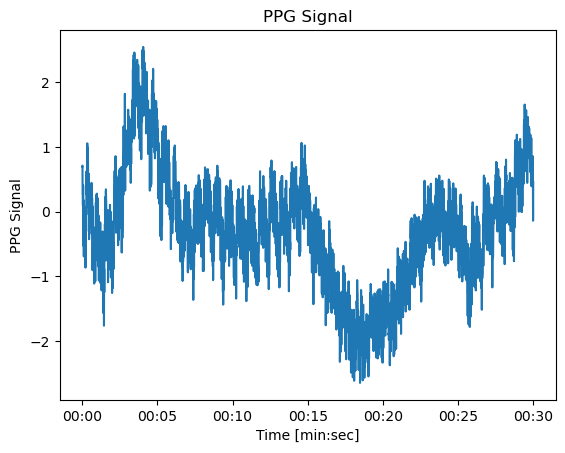

In [5]:
# plot the first 30 seconds of the unfiltered ppg signal of the first window
plot_signal(X_test[19][0:30*FS], 'PPG Signal', 'PPG Signal')

# Pre-Training

## PREPROCESSING

In [6]:
# PREPROCESSING
# Replace direct high-pass filtering with polynomial baseline subtraction.
# This keeps the pulse morphology but removes slow drift more gently.

from scipy import signal
import numpy as np

def lowpass_filter(ppg_window, fs=100, cutoff_hz=10.0, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    sos = signal.butter(order, normal_cutoff, btype='lowpass', output='sos')
    return signal.sosfiltfilt(sos, ppg_window)

def preprocess_window(ppg_window, fs=100, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0, poly_degree=3):
    # keep hp_cutoff_hz in the signature so the rest of the notebook does not break
    # even though we are no longer using a direct high-pass filter

    t = np.linspace(-1, 1, len(ppg_window))
    coeffs = np.polyfit(t, ppg_window, poly_degree)
    baseline = np.polyval(coeffs, t)

    x = ppg_window - baseline
    x = lowpass_filter(x, fs=fs, cutoff_hz=lp_cutoff_hz, order=4)
    return x

## EXTRACT RESPIRATORY SIGNALS

In [7]:
# RESAMPLE RESPIRATORY SIGNALS

from scipy.interpolate import CubicSpline

RESP_FS = 4  # higher than nyquist frequency (2 x 0.6 Hz)


def resample_resp(ppg_window, extract_fn, fs=100, resp_fs=RESP_FS):
    
    # find peaks and troughs (use maximum heart rate of ~150 bpm)
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)
    troughs, _ = signal.find_peaks(-ppg_window, distance=int(0.4 * fs))

    beat_times = []
    beat_values = []

    if extract_fn == 'bw':
        for pk in peaks:\

            # pair up peaks and troughs
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]

            # append to list
            beat_times.append(pk / fs)
            beat_values.append((ppg_window[pk] + ppg_window[tr]) / 2.0)

    elif extract_fn == 'am':
        for pk in peaks:

            # pair up peaks and troughs
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]

            # append to list
            beat_times.append(pk / fs)
            beat_values.append(ppg_window[pk] - ppg_window[tr])

    elif extract_fn == 'fm':

        # check if there are at least 3 peaks, otherwise peak detection failed
        if len(peaks) < 3:
            duration = len(ppg_window) / fs
            n_out = int(duration * resp_fs)
            return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

        # calculate inter-beat interval
        ibi = np.diff(peaks).astype(float) / fs

        # append to list
        beat_times = (peaks[1:] / fs).tolist()
        beat_values = ibi.tolist()

    beat_times = np.array(beat_times)
    beat_values = np.array(beat_values)

    # check if there are at least 3 peaks, otherwise peak detection failed
    if len(beat_times) < 3:
        duration = len(ppg_window) / fs
        n_out = int(duration * resp_fs)
        return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

    # uniform time grid at resp_fs Hz spanning the beat-time range
    duration = len(ppg_window) / fs
    t_uniform = np.linspace(0, duration, int(duration * resp_fs), endpoint=False)

    # cubic spline interpolation (clamp to beat-time range to avoid extrapolation artefacts)
    cs = CubicSpline(beat_times, beat_values, extrapolate=True)
    resampled = cs(t_uniform)

    return resampled, t_uniform


## Create ML Input Features

In [24]:
from scipy import signal
import numpy as np

def extract_signal_features(resp_signal, resp_fs=4, br_low_bpm=8, br_high_bpm=40):

    x = np.asarray(resp_signal, dtype=float)

    # Safety
    if len(x) < 8 or np.allclose(x, 0):
        return {
            'dom_freq_hz': 0.0,
            'dom_bpm': 0.0,
            'peak_power': 0.0,
            'band_power': 0.0,
            'peak_to_band_ratio': 0.0,
            'signal_mean': 0.0,
            'signal_std': 0.0,
        }

    # remove mean
    x = x - np.mean(x)

    # welch PSD
    freqs, psd = signal.welch(
        x,
        fs=resp_fs,
        nperseg=min(len(x), 256),
        noverlap=min(len(x), 256) // 2
    )

    # respiratory band mask
    low_hz = br_low_bpm / 60.0
    high_hz = br_high_bpm / 60.0
    mask = (freqs >= low_hz) & (freqs <= high_hz)

    if not np.any(mask):
        return {
            'dom_freq_hz': 0.0,
            'dom_bpm': 0.0,
            'peak_power': 0.0,
            'band_power': 0.0,
            'peak_to_band_ratio': 0.0,
            'signal_mean': float(np.mean(x)),
            'signal_std': float(np.std(x)),
        }

    freqs_band = freqs[mask]
    psd_band = psd[mask]

    if len(psd_band) == 0 or np.allclose(psd_band, 0):
        dom_freq = 0.0
        peak_power = 0.0
        band_power = 0.0
        peak_to_band_ratio = 0.0
    else:
        idx = np.argmax(psd_band)
        dom_freq = freqs_band[idx]
        peak_power = psd_band[idx]
        band_power = np.sum(psd_band)
        peak_to_band_ratio = peak_power / (band_power + 1e-8)

    return {
        'dom_freq_hz': float(dom_freq),
        'dom_bpm': float(dom_freq * 60.0),
        'peak_power': float(peak_power),
        'band_power': float(band_power),
        'peak_to_band_ratio': float(peak_to_band_ratio),
        'signal_mean': float(np.mean(x)),
        'signal_std': float(np.std(x)),
    }



def extract_subwindow_stability(resp_signal, resp_fs=4, n_chunks=3):
    x = np.asarray(resp_signal, dtype=float)

    # Split into equal chunks, e.g. 3 x 40 s for a 120 s window
    chunks = np.array_split(x, n_chunks)

    chunk_bpms = []
    for ch in chunks:
        ch = np.asarray(ch, dtype=float)

        # very flat / tiny chunk safeguard
        if len(ch) < 16 or np.std(ch) < 1e-8:
            chunk_bpms.append(0.0)
            continue

        feat = extract_signal_features(ch, resp_fs=resp_fs)
        chunk_bpms.append(float(feat['dom_bpm']))

    chunk_bpms = np.asarray(chunk_bpms, dtype=float)

    return {
        'chunk_bpm_mean': float(np.mean(chunk_bpms)),
        'chunk_bpm_std': float(np.std(chunk_bpms)),
        'chunk_bpm_range': float(np.max(chunk_bpms) - np.min(chunk_bpms)),
    }


def extract_acf_features(resp_signal, resp_fs=4, br_low_bpm=8, br_high_bpm=40):
    x = np.asarray(resp_signal, dtype=float)
    x = x - np.mean(x)

    # guard against flat / invalid signals
    if len(x) < 8 or np.std(x) < 1e-8:
        return {
            'acf_dom_bpm': 0.0,
            'acf_peak_value': 0.0
        }

    # autocorrelation, keep non-negative lags only
    acf = np.correlate(x, x, mode='full')
    acf = acf[len(acf)//2:]

    # normalize
    if acf[0] <= 0:
        return {
            'acf_dom_bpm': 0.0,
            'acf_peak_value': 0.0
        }
    acf = acf / (acf[0] + 1e-8)

    # convert respiratory range to lag range
    # bpm = 60 * fs / lag  -> lag = 60 * fs / bpm
    min_lag = max(1, int(np.floor(60.0 * resp_fs / br_high_bpm)))
    max_lag = min(len(acf) - 1, int(np.ceil(60.0 * resp_fs / br_low_bpm)))

    if max_lag <= min_lag:
        return {
            'acf_dom_bpm': 0.0,
            'acf_peak_value': 0.0
        }

    acf_band = acf[min_lag:max_lag + 1]

    # prefer actual peaks; fallback to argmax if none found
    peak_idx, _ = signal.find_peaks(acf_band)
    if len(peak_idx) > 0:
        best_rel = peak_idx[np.argmax(acf_band[peak_idx])]
    else:
        best_rel = int(np.argmax(acf_band))

    best_lag = min_lag + best_rel
    best_peak = float(acf[best_lag])
    acf_dom_bpm = 60.0 * resp_fs / best_lag

    return {
        'acf_dom_bpm': float(acf_dom_bpm),
        'acf_peak_value': best_peak
    }

In [25]:
def extract_window_features(ppg_window, fs=FS, resp_fs=RESP_FS):

    # same preprocessing used during training
    x = preprocess_window(ppg_window, fs=fs, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0)

    # respiratory surrogates
    bw, _ = resample_resp(x, 'bw', fs=fs, resp_fs=resp_fs)
    am, _ = resample_resp(x, 'am', fs=fs, resp_fs=resp_fs)
    fm, _ = resample_resp(x, 'fm', fs=fs, resp_fs=resp_fs)

    bw_feat = extract_signal_features(bw, resp_fs=resp_fs)
    am_feat = extract_signal_features(am, resp_fs=resp_fs)
    fm_feat = extract_signal_features(fm, resp_fs=resp_fs)

    bw_acf = extract_acf_features(bw, resp_fs=resp_fs)
    am_acf = extract_acf_features(am, resp_fs=resp_fs)
    fm_acf = extract_acf_features(fm, resp_fs=resp_fs)

    bw_stab = extract_subwindow_stability(bw, resp_fs=resp_fs, n_chunks=3)
    am_stab = extract_subwindow_stability(am, resp_fs=resp_fs, n_chunks=3)
    fm_stab = extract_subwindow_stability(fm, resp_fs=resp_fs, n_chunks=3)

    # simple PPG quality / morphology features
    peaks, peak_props = signal.find_peaks(
        x,
        distance=int(0.4 * fs),
        prominence=0
    )
    troughs, _ = signal.find_peaks(-x, distance=int(0.4 * fs))

    mean_prom = float(np.mean(peak_props['prominences'])) if len(peaks) > 0 and 'prominences' in peak_props else 0.0
    peak_count = int(len(peaks))
    trough_count = int(len(troughs))

    # final flat feature vector
    feats = [
        bw_feat['dom_bpm'],
        bw_feat['peak_power'],
        bw_feat['band_power'],
        bw_feat['peak_to_band_ratio'],
        bw_feat['signal_std'],

        am_feat['dom_bpm'],
        am_feat['peak_power'],
        am_feat['band_power'],
        am_feat['peak_to_band_ratio'],
        am_feat['signal_std'],

        fm_feat['dom_bpm'],
        fm_feat['peak_power'],
        fm_feat['band_power'],
        fm_feat['peak_to_band_ratio'],
        fm_feat['signal_std'],

        bw_stab['chunk_bpm_mean'], bw_stab['chunk_bpm_std'], bw_stab['chunk_bpm_range'],
        am_stab['chunk_bpm_mean'], am_stab['chunk_bpm_std'], am_stab['chunk_bpm_range'],
        fm_stab['chunk_bpm_mean'], fm_stab['chunk_bpm_std'], fm_stab['chunk_bpm_range'],

        bw_acf['acf_dom_bpm'], bw_acf['acf_peak_value'],
        am_acf['acf_dom_bpm'], am_acf['acf_peak_value'],
        fm_acf['acf_dom_bpm'], fm_acf['acf_peak_value'],

        peak_count,
        trough_count,
        mean_prom,
        float(np.std(x)),
        float(np.mean(x)),
    ]

    return np.array(feats, dtype=float)

In [29]:
# full feature matrix

feature_names = [
    'bw_dom_bpm', 'bw_peak_power', 'bw_band_power', 'bw_peak_to_band_ratio', 'bw_signal_std',
    'am_dom_bpm', 'am_peak_power', 'am_band_power', 'am_peak_to_band_ratio', 'am_signal_std',
    'fm_dom_bpm', 'fm_peak_power', 'fm_band_power', 'fm_peak_to_band_ratio', 'fm_signal_std',

    'bw_chunk_bpm_mean', 'bw_chunk_bpm_std', 'bw_chunk_bpm_range',
    'am_chunk_bpm_mean', 'am_chunk_bpm_std', 'am_chunk_bpm_range',
    'fm_chunk_bpm_mean', 'fm_chunk_bpm_std', 'fm_chunk_bpm_range',

    'bw_acf_dom_bpm', 'bw_acf_peak_value',
    'am_acf_dom_bpm', 'am_acf_peak_value',
    'fm_acf_dom_bpm', 'fm_acf_peak_value',

    'peak_count', 'trough_count', 'mean_prom', 'ppg_std', 'ppg_mean',
]

def build_feature_matrix(X_windows, fs=FS, resp_fs=RESP_FS):
    return np.array([extract_window_features(w, fs=fs, resp_fs=resp_fs) for w in X_windows])

X_train_feat = build_feature_matrix(X_train, fs=FS, resp_fs=RESP_FS)
X_test_feat  = build_feature_matrix(X_test, fs=FS, resp_fs=RESP_FS)

print("X_train_feat shape:", X_train_feat.shape)
print("X_test_feat shape:", X_test_feat.shape)

X_train_feat shape: (643, 35)
X_test_feat shape: (645, 35)


## ML Modeling and Training

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_feat, y_train, test_size=0.2, random_state=42
)

print(X_tr.shape, X_val.shape)

(514, 35) (129, 35)


### XGBoost

In [31]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 400, 800],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.7, 0.85],
    'colsample_bytree': [0.7, 0.85],
    'min_child_weight': [3, 5],
    'reg_lambda': [3.0, 10.0],
    'reg_alpha': [0.0, 0.5],
    'gamma': [0.0, 0.1]
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tr, y_tr)

print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best CV MAE: 3.0096700962587115
Best params: {'colsample_bytree': 0.85, 'gamma': 0.0, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 800, 'reg_alpha': 0.5, 'reg_lambda': 3.0, 'subsample': 0.85}


In [32]:
from sklearn.metrics import mean_absolute_error

xgb_es = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    **grid.best_params_
)

xgb_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_tr_pred = xgb_es.predict(X_tr)
y_val_pred = xgb_es.predict(X_val)

train_mae = mean_absolute_error(y_tr, y_tr_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print("Train MAE:", train_mae)
print("Validation MAE:", val_mae)
print("Gap:", val_mae - train_mae)
print("Best iteration:", xgb_es.best_iteration)

Train MAE: 0.6156418175731081
Validation MAE: 3.041798384298649
Gap: 2.426156566725541
Best iteration: 319


In [33]:
best_n = xgb_es.best_iteration + 1

final_params = grid.best_params_.copy()
final_params['n_estimators'] = best_n

xgb_final = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    n_jobs=-1,
    **final_params
)

xgb_final.fit(X_train_feat, y_train)

print("Final XGBoost trained on full training set.")
print("Final n_estimators used:", best_n)

Final XGBoost trained on full training set.
Final n_estimators used: 320


## Submission

In [35]:
# function to predict BR for a single 120-second window

def predict_br(ppg_window):
    x = extract_window_features(ppg_window, fs=FS, resp_fs=RESP_FS).reshape(1, -1)

    pred = xgb_final.predict(x)[0]

    # match label / assignment format
    pred = np.clip(pred, 8, 40)
    pred = np.round(pred * 2) / 2

    return [float(pred)]

In [36]:
# function to print the mean absolute error between your predicted BR and the BR labels
# with this function, you can evaluate the resulting score that you would obtain on the test set
# with your predicted BR values
def print_score(pred_br, label_br):
    err = np.abs(np.asarray(pred_br) - np.asarray(label_br))
    print("Mean absolute error: {:4.3f}".format(np.mean(err)))

In [37]:
# create the submission file called "submission.csv"
# download the file and submit it to the kaggle competition to obtain a score on the leaderboard
idxs = []
preds = []

# loop through all test windows
# important: loop through the windows as below, add the predictions in the same order and keep the naming of window{i}_{j}
# we will only evaluate your predictions for the test set
for i, ppg in enumerate(X_test):
    # index needed for kaggle submission file
    idxs.extend([i])
    # your predictions based on the above function
    preds.extend(predict_br(ppg))

# on the right side in tab "Output", you should now see a file called "submission.csv" after pressing the refresh button
# download the file and submit it to this competition to obtain a score on the leaderboard
df = pd.DataFrame({'Id': idxs, 'Predicted': preds})
# df.to_csv('/kaggle/working/submission.csv', index=False)  # for Kaggle
df.to_csv('./submission.csv', index=False)  # when running locally

In [44]:
# example on how to use the print_score function with randomly generated BR values as the predictions and labels
pred_br_random = list(np.random.randint(8, 40, len(preds)))
label_br_random = list(np.random.randint(8, 40, len(preds)))
print_score(pred_br_random, label_br_random)

Mean absolute error: 10.518


## Visualize Errors

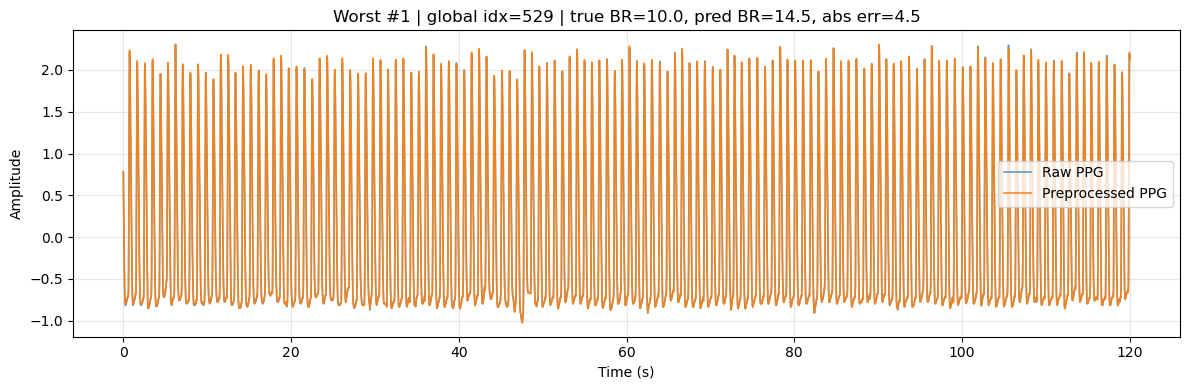

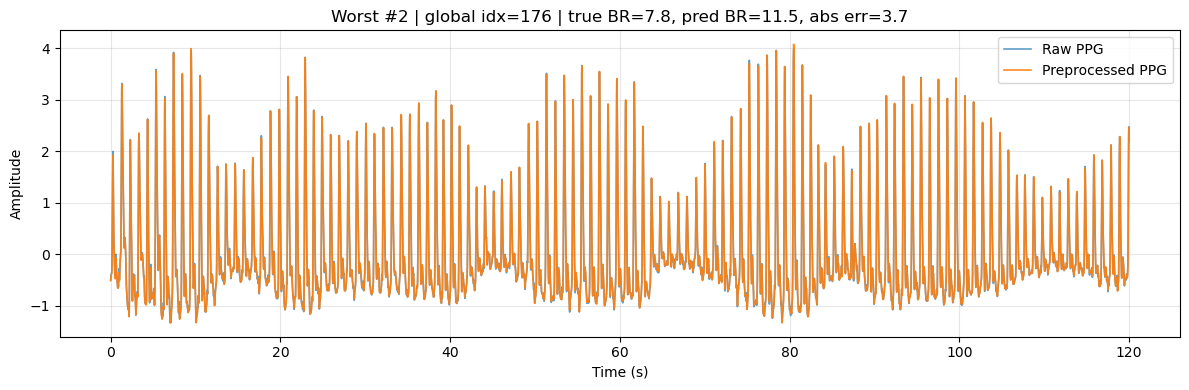

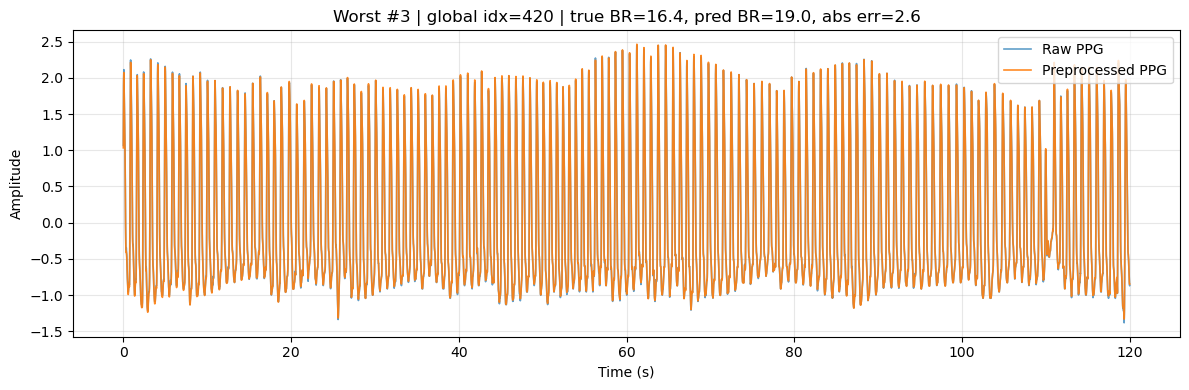

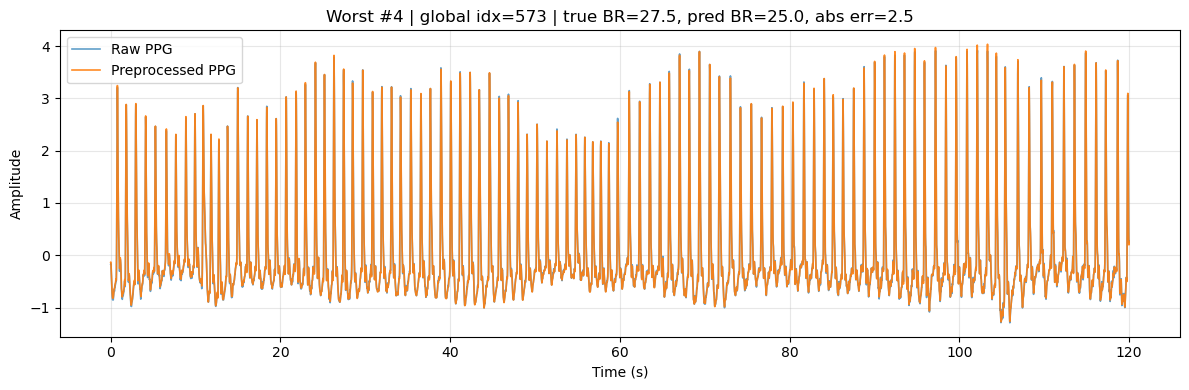

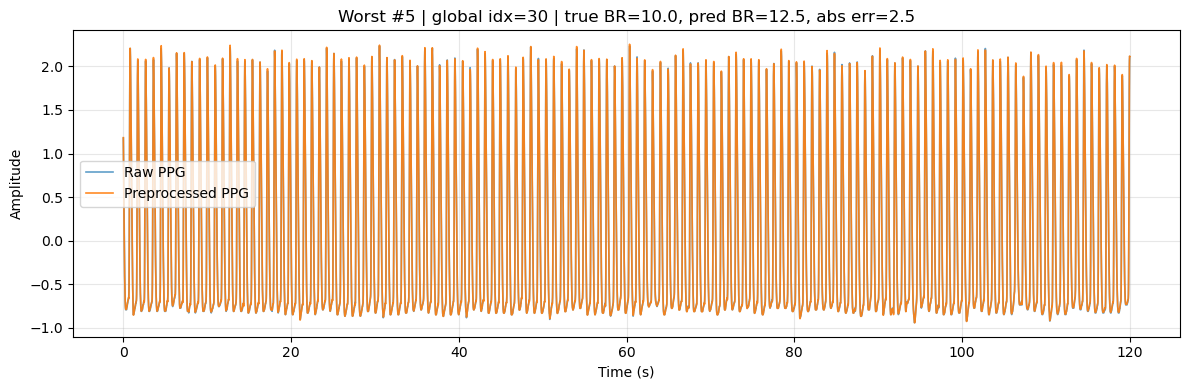

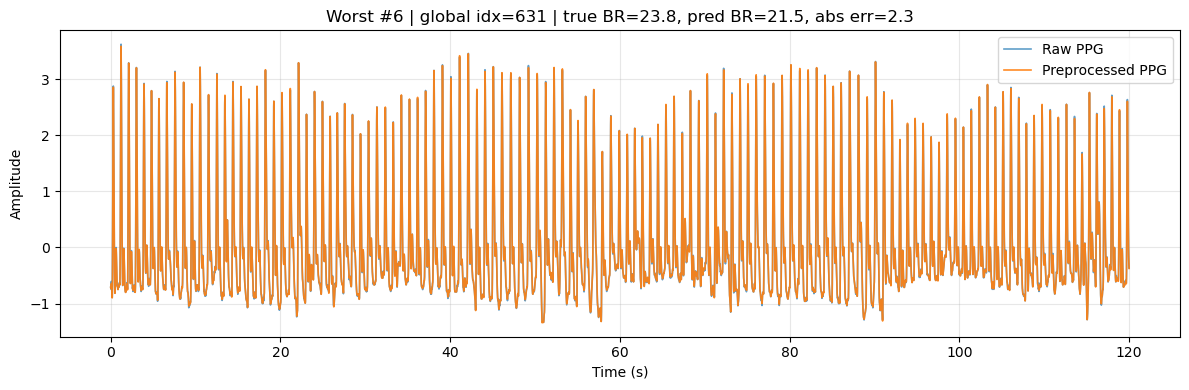

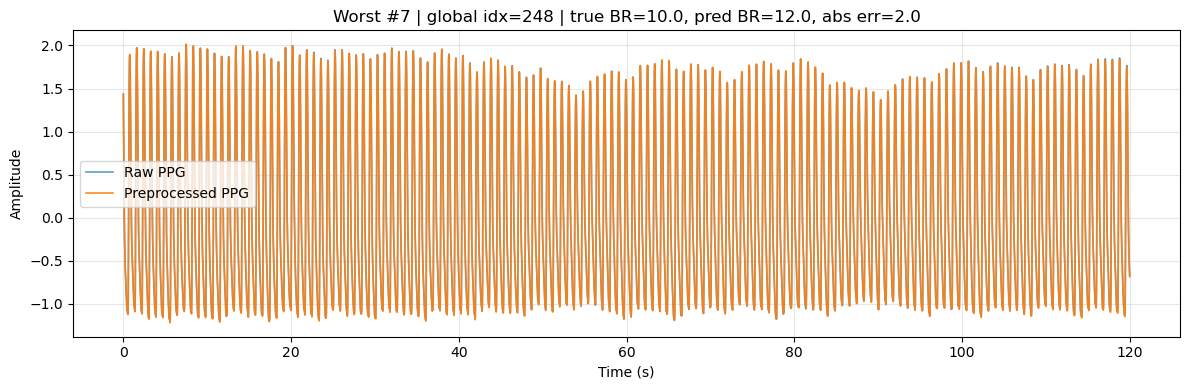

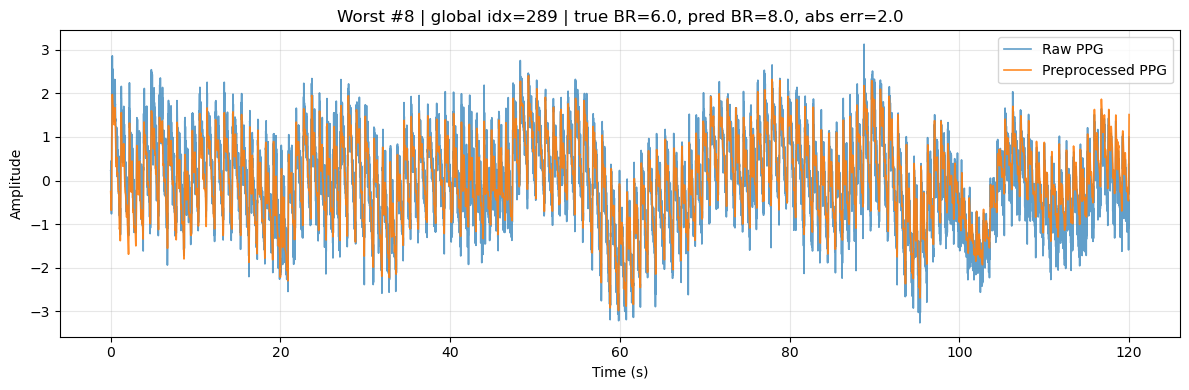

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# choose the trained model you want to inspect
model = xgb_final

# rebuild the same validation split using indices
all_idx = np.arange(len(X_train))
_, idx_val = train_test_split(
    all_idx, test_size=0.2, random_state=42
)

# validation data
X_val_raw = X_train[idx_val]
X_val_feat = X_train_feat[idx_val]
y_val_true = y_train[idx_val]

# predictions
y_val_pred = model.predict(X_val_feat)

# optional: apply same post-processing as elsewhere in your notebook
y_val_pred = np.clip(y_val_pred, 8, 40)
y_val_pred = np.round(y_val_pred * 2) / 2

# errors
abs_err = np.abs(y_val_pred - y_val_true)
worst_order = np.argsort(abs_err)[::-1]

# how many worst examples to inspect
n_show = 8

for rank, local_idx in enumerate(worst_order[:n_show], start=1):
    raw_window = X_val_raw[local_idx]
    pre_window = preprocess_window(raw_window, fs=FS, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0)

    pred = y_val_pred[local_idx]
    true = y_val_true[local_idx]
    err = abs_err[local_idx]
    global_idx = idx_val[local_idx]

    t = np.arange(len(raw_window)) / FS

    plt.figure(figsize=(12, 4))
    plt.plot(t, raw_window, label="Raw PPG", alpha=0.7, linewidth=1.2)
    plt.plot(t, pre_window, label="Preprocessed PPG", alpha=0.9, linewidth=1.2)

    plt.title(
        f"Worst #{rank} | global idx={global_idx} | "
        f"true BR={true:.1f}, pred BR={pred:.1f}, abs err={err:.1f}"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()